# Trading Strategy & Backtesting Engine (Professional Version)
This notebook implements a statistical arbitrage pairs trading strategy using **WMT** and **TGT**, including **Rolling Hedge Ratios** and **Transaction Costs**.


## 1. Import Libraries


In [185]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from statsmodels.tsa.stattools import adfuller
import seaborn as sns


## 2. Fetch Data


In [175]:
start_date = '2020-01-01'
end_date = '2024-01-01'
tickers = ['WMT', 'TGT']
data = yf.download(tickers, start=start_date, end=end_date)['Close']


[*********************100%***********************]  2 of 2 completed


## 3. Calculate Rolling Hedge Ratio


In [176]:
x = data['TGT']
y = data['WMT']
x_const = sm.add_constant(x)

window_ols = 60
model = RollingOLS(y, x_const, window=window_ols)
rolling_res = model.fit()
hedge_ratios = rolling_res.params['TGT']


## 4. Calculate Spread and Z-Score


<Axes: xlabel='Date'>

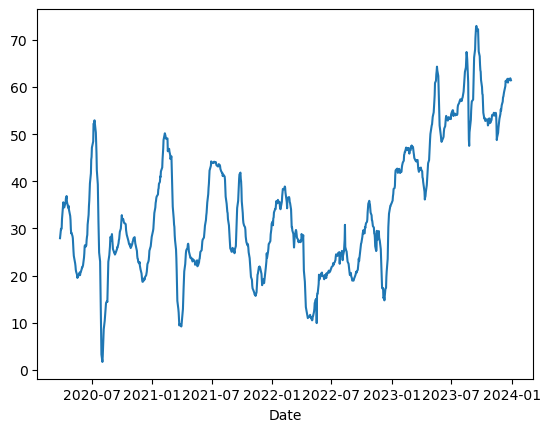

In [186]:
spread = data['WMT'] - hedge_ratios * data['TGT']

window = 30
spread_mean = spread.rolling(window=window).mean()
spread_std = spread.rolling(window=window).std()
z_score = (spread - spread_mean) / spread_std
sns.lineplot(spread)

## 5. Generate Trading Signals


In [202]:
entry_threshold = 1.2
exit_threshold = 0.0

positions = pd.DataFrame(index=z_score.index)
positions['WMT'] = 0
positions['TGT'] = 0

long_spread = z_score < -entry_threshold
short_spread = z_score > entry_threshold
exit_spread = abs(z_score) < 0.5

positions['signal'] = np.select(
    [long_spread, short_spread],
    [1, -1],
    default=0
)

# Forward fill the signals
positions['signal'] = positions['signal'].replace(0, np.nan).ffill().fillna(0)


## 6. Calculate Returns with Transaction Costs
We account for a **0.1% cost per trade** (slippage and commissions) to make the backtest more realistic.


In [203]:
daily_returns = data.pct_change()

# Raw strategy returns (ignoring costs)
strategy_returns = positions['signal'].shift(1) * (daily_returns['WMT'] - hedge_ratios.shift(1) * daily_returns['TGT'])

# Calculate Transaction Costs
cost_per_trade = 0.0001  # 0.01%
trades = positions['signal'].diff().fillna(0).abs()
transaction_costs = trades * cost_per_trade

# Final Adjusted Returns
strategy_returns = strategy_returns - transaction_costs
strategy_returns


Date
2020-01-02         NaN
2020-01-03         NaN
2020-01-06         NaN
2020-01-07         NaN
2020-01-08         NaN
                ...   
2023-12-22   -0.012461
2023-12-26    0.001040
2023-12-27   -0.010181
2023-12-28    0.001874
2023-12-29   -0.000441
Length: 1006, dtype: float64

## 7. Visualize Z-Score and Thresholds


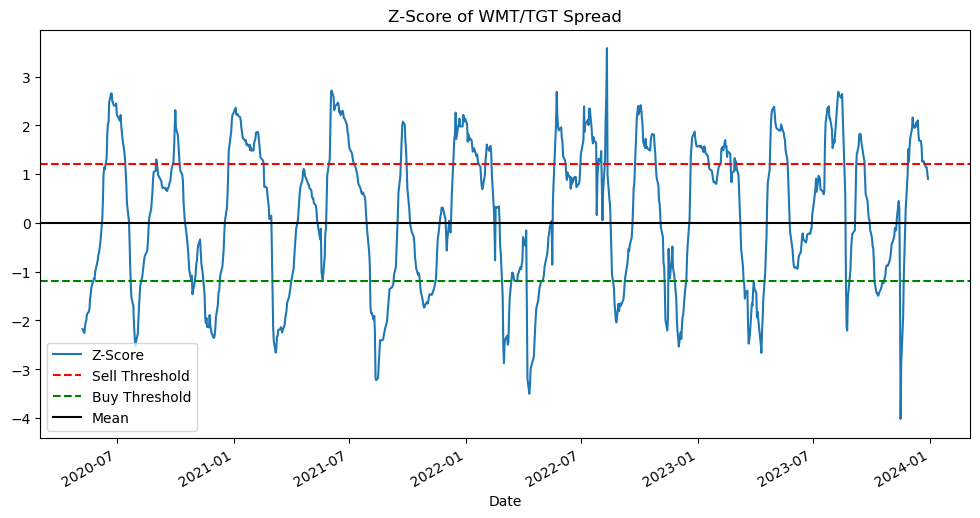

In [204]:
plt.figure(figsize=(12, 6))
plt.title('Z-Score of WMT/TGT Spread')
z_score.plot(label='Z-Score')
plt.axhline(entry_threshold, color='r', linestyle='--', label='Sell Threshold')
plt.axhline(-entry_threshold, color='g', linestyle='--', label='Buy Threshold')
plt.axhline(0, color='black', linestyle='-', label='Mean')
plt.legend()
plt.show()


## 8. Visualize Cumulative Returns


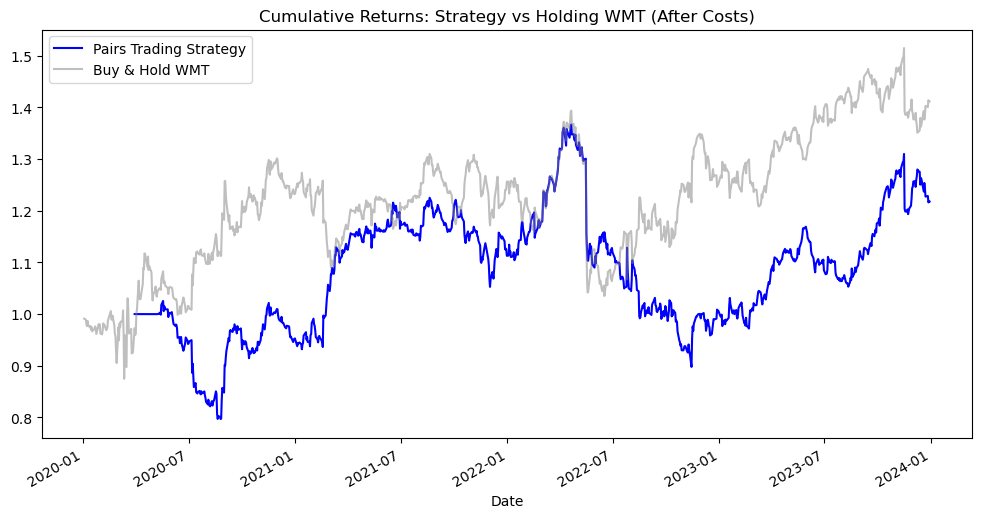

In [205]:
cumulative_strategy_returns = (1 + strategy_returns).cumprod()
cumulative_wmt_returns = (1 + daily_returns['WMT']).cumprod()

plt.figure(figsize=(12, 6))
plt.title('Cumulative Returns: Strategy vs Holding WMT (After Costs)')
cumulative_strategy_returns.plot(label='Pairs Trading Strategy', color='blue')
cumulative_wmt_returns.plot(label='Buy & Hold WMT', color='gray', alpha=0.5)
plt.legend()
plt.show()


## 9. Performance Metrics


In [206]:
sharpe_ratio = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252)
print(f'Strategy Sharpe Ratio: {sharpe_ratio:.2f}')
print(f'Total Transaction Costs Paid: {transaction_costs.sum():.2%}')


Strategy Sharpe Ratio: 0.37
Total Transaction Costs Paid: 0.47%
